In [1]:
import os
import pickle
import numpy as np

OUTPUT_DIR = "/home/user/22059240/FYP/processed"

WINDOW_SIZE = 30
FEATURE_DIM = 166

In [2]:
X_train = np.load(os.path.join(OUTPUT_DIR, "X_train.npy"))
y_train = np.load(os.path.join(OUTPUT_DIR, "y_train.npy"))
X_test  = np.load(os.path.join(OUTPUT_DIR, "X_test.npy"))
y_test  = np.load(os.path.join(OUTPUT_DIR, "y_test.npy"))

with open(os.path.join(OUTPUT_DIR, "class_weights.pkl"), "rb") as f:
    class_weight_dict = pickle.load(f)

print("Data loaded successfully.")
print(f"X_train : {X_train.shape}")
print(f"y_train : {y_train.shape}")
print(f"X_test  : {X_test.shape}")
print(f"y_test  : {y_test.shape}")
print(f"Class weights: {class_weight_dict}")

print("=" * 55)
print("PRE-TRAINING SUMMARY")
print("=" * 55)

print(f"Input shape (per sample) : ({WINDOW_SIZE}, {FEATURE_DIM})")
print(f"Training samples         : {X_train.shape[0]}")
print(f"  Fall                   : {y_train.sum()}")
print(f"  Non-fall               : {(y_train == 0).sum()}")

print(f"Test samples             : {X_test.shape[0]}")
print(f"  Fall                   : {y_test.sum()}")
print(f"  Non-fall               : {(y_test == 0).sum()}")

print(f"Class weights            : {class_weight_dict}")

print("Feature vector breakdown:")
print("  BlazePose keypoints    : 33 × 4 = 132")
print("  Vertical velocity      : 33")
print("  Body aspect ratio      : 1")
print(f"  Total                  : {FEATURE_DIM}")

print("=" * 55)
print("Ready for model training.")

Data loaded successfully.
X_train : (3123, 30, 166)
y_train : (3123,)
X_test  : (243, 30, 166)
y_test  : (243,)
Class weights: {0: 0.8032407407407407, 1: 1.3244274809160306}
PRE-TRAINING SUMMARY
Input shape (per sample) : (30, 166)
Training samples         : 3123
  Fall                   : 1179
  Non-fall               : 1944
Test samples             : 243
  Fall                   : 53
  Non-fall               : 190
Class weights            : {0: 0.8032407407407407, 1: 1.3244274809160306}
Feature vector breakdown:
  BlazePose keypoints    : 33 × 4 = 132
  Vertical velocity      : 33
  Body aspect ratio      : 1
  Total                  : 166
Ready for model training.


In [3]:
#Imports

import os
import numpy as np
import pickle
import time
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import (
    LSTM, GRU, Dense, Dropout, Bidirectional,
    Conv1D, MaxPooling1D
)
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, CSVLogger
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, precision_score, recall_score, f1_score
)
import seaborn as sns

print("TensorFlow version:", tf.__version__)
print("All training libraries imported.")

2026-10-01 22:31:01.000501: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:479] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-10-01 22:31:01.021841: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:10575] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-10-01 22:31:01.021871: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1442] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-10-01 22:31:01.039248: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-10-01 22:31:11.201948: W tensorflow/compiler/tf

TensorFlow version: 2.16.2
All training libraries imported.


In [4]:
#Load preprocessed data 

OUTPUT_DIR = "/home/user/22059240/FYP/processed"
MODELS_DIR = "/home/user/22059240/FYP/models"
LOGS_DIR   = "/home/user/22059240/FYP/logs"

os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(LOGS_DIR,   exist_ok=True)

X_train = np.load(os.path.join(OUTPUT_DIR, "X_train.npy"))
y_train = np.load(os.path.join(OUTPUT_DIR, "y_train.npy"))
X_test  = np.load(os.path.join(OUTPUT_DIR, "X_test.npy"))
y_test  = np.load(os.path.join(OUTPUT_DIR, "y_test.npy"))

with open(os.path.join(OUTPUT_DIR, "class_weights.pkl"), "rb") as f:
    class_weight_dict = pickle.load(f)

WINDOW_SIZE  = 30
FEATURE_DIM  = 166
RANDOM_SEED  = 42

tf.random.set_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print("Data loaded.")
print(f"  X_train : {X_train.shape}  |  y_train : {y_train.shape}")
print(f"  X_test  : {X_test.shape}   |  y_test  : {y_test.shape}")
print(f"  Class weights: {class_weight_dict}")

Data loaded.
  X_train : (3123, 30, 166)  |  y_train : (3123,)
  X_test  : (243, 30, 166)   |  y_test  : (243,)
  Class weights: {0: 0.8032407407407407, 1: 1.3244274809160306}


In [5]:
#Training config 

LEARNING_RATE = 0.001
BATCH_SIZE    = 32
MAX_EPOCHS    = 100
PATIENCE      = 10
DROPOUT_RATE  = 0.3
VAL_SPLIT     = 0.10

def get_callbacks(model_name):
    """
    Returns EarlyStopping, ModelCheckpoint and CSVLogger
    for a given model name.
    """
    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=PATIENCE,
        restore_best_weights=True,
        verbose=1
    )
    checkpoint = ModelCheckpoint(
        filepath=os.path.join(MODELS_DIR, f"{model_name}_best.keras"),
        monitor='val_loss',
        save_best_only=True,
        verbose=0
    )
    csv_log = CSVLogger(
        os.path.join(LOGS_DIR, f"{model_name}_training_log.csv"),
        append=False
    )
    return [early_stop, checkpoint, csv_log]

print("Training configuration set.")
print(f"  Learning rate : {LEARNING_RATE}")
print(f"  Batch size    : {BATCH_SIZE}")
print(f"  Max epochs    : {MAX_EPOCHS}")
print(f"  Early stop    : patience={PATIENCE}")
print(f"  Dropout rate  : {DROPOUT_RATE}")
print(f"  Val split     : {VAL_SPLIT}")

Training configuration set.
  Learning rate : 0.001
  Batch size    : 32
  Max epochs    : 100
  Early stop    : patience=10
  Dropout rate  : 0.3
  Val split     : 0.1


In [6]:
#Simple LSTM

input_shape = (WINDOW_SIZE, FEATURE_DIM)

def build_simple_lstm(input_shape, dropout_rate=DROPOUT_RATE):
    model = Sequential([
        LSTM(64, input_shape=input_shape, return_sequences=False),
        Dropout(dropout_rate),
        Dense(1, activation='sigmoid')
    ], name="Simple_LSTM")
    model.compile(
        optimizer=Adam(learning_rate=LEARNING_RATE),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

model_simple_lstm = build_simple_lstm(input_shape)
model_simple_lstm.summary()

2026-10-01 22:31:54.987940: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2251] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...
/home/user/22059240/fyp-env/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "Simple_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        59,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 59,201 (231.25 KB)

 Trainable params: 59,201 (231.25 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
print("Training Model 1: Simple LSTM...")
start = time.time()

history_simple_lstm = model_simple_lstm.fit(
    X_train, y_train,
    epochs=MAX_EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=VAL_SPLIT,
    class_weight=class_weight_dict,
    callbacks=get_callbacks("simple_lstm"),
    verbose=1
)

print(f"\nSimple LSTM training complete. Time: {(time.time()-start)/60:.2f} min")

Training Model 1: Simple LSTM...
Epoch 1/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.7157 - loss: 0.5480 - val_accuracy: 0.8179 - val_loss: 0.4436
Epoch 2/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8064 - loss: 0.3985 - val_accuracy: 0.9201 - val_loss: 0.3044
Epoch 3/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8555 - loss: 0.3207 - val_accuracy: 0.9361 - val_loss: 0.2231
Epoch 4/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8445 - loss: 0.3332 - val_accuracy: 0.8275 - val_loss: 0.3849
Epoch 5/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8722 - loss: 0.2908 - val_accuracy: 0.9073 - val_loss: 0.2310
Epoch 6/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8840 - loss: 0.2620 - val_accuracy: 0.9233 - val_loss: 0.1864
Epoch 7/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8915 - loss: 0.2413 - val_accuracy: 0.9521 - val_loss: 0.1741
Epoch 8/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8950 - loss:

In [8]:
#Stacked LSTM

def build_stacked_lstm(input_shape, dropout_rate=DROPOUT_RATE):
    model = Sequential([
        LSTM(64, input_shape=input_shape, return_sequences=True),
        Dropout(dropout_rate),
        LSTM(64, return_sequences=False),
        Dropout(dropout_rate),
        Dense(1, activation='sigmoid')
    ], name="Stacked_LSTM")
    model.compile(
        optimizer=Adam(learning_rate=LEARNING_RATE),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

model_stacked_lstm = build_stacked_lstm(input_shape)
model_stacked_lstm.summary()

print("\nTraining Model 2: Stacked LSTM...")
start = time.time()

history_stacked_lstm = model_stacked_lstm.fit(
    X_train, y_train,
    epochs=MAX_EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=VAL_SPLIT,
    class_weight=class_weight_dict,
    callbacks=get_callbacks("stacked_lstm"),
    verbose=1
)

print(f"Stacked LSTM training complete. Time: {(time.time()-start)/60:.2f} min")

Model: "Stacked_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 30, 64)         │        59,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 92,225 (360.25 KB)

 Trainable params: 92,225 (360.25 KB)

 Non-trainable params: 0 (0.00 B)


Training Model 2: Stacked LSTM...
Epoch 1/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.7028 - loss: 0.5388 - val_accuracy: 0.8435 - val_loss: 0.3580
Epoch 2/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.8246 - loss: 0.3660 - val_accuracy: 0.9169 - val_loss: 0.2929
Epoch 3/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.8591 - loss: 0.3166 - val_accuracy: 0.8786 - val_loss: 0.2569
Epoch 4/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.8680 - loss: 0.2747 - val_accuracy: 0.9361 - val_loss: 0.2032
Epoch 5/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.8986 - loss: 0.2302 - val_accuracy: 0.8850 - val_loss: 0.2813
Epoch 6/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.8765 - loss: 0.2551 - val_accuracy: 0.9105 - val_loss: 0.2151
Epoch 7/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.8940 - loss: 0.2195 - val_accuracy: 0.9265 - val_loss: 0.1552
Epoch 8/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.895

In [12]:
#BiLSTM

def build_bilstm(input_shape, dropout_rate=DROPOUT_RATE):
    model = Sequential([
        Bidirectional(
            LSTM(64, return_sequences=False),
            input_shape=input_shape
        ),
        Dropout(dropout_rate),
        Dense(1, activation='sigmoid')
    ], name="BiLSTM")
    model.compile(
        optimizer=Adam(learning_rate=LEARNING_RATE),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

model_bilstm = build_bilstm(input_shape)
model_bilstm.summary()

print("\nTraining Model 3: BiLSTM...")
start = time.time()

history_bilstm = model_bilstm.fit(
    X_train, y_train,
    epochs=MAX_EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=VAL_SPLIT,
    class_weight=class_weight_dict,
    callbacks=get_callbacks("bilstm"),
    verbose=1
)

print(f"BiLSTM training complete. Time: {(time.time()-start)/60:.2f} min")

/home/user/22059240/fyp-env/lib/python3.12/site-packages/keras/src/layers/rnn/bidirectional.py:110: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "BiLSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 128)            │       118,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 118,401 (462.50 KB)

 Trainable params: 118,401 (462.50 KB)

 Non-trainable params: 0 (0.00 B)


Training Model 3: BiLSTM...
Epoch 1/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.7288 - loss: 0.5174 - val_accuracy: 0.8786 - val_loss: 0.3458
Epoch 2/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7854 - loss: 0.4282 - val_accuracy: 0.9073 - val_loss: 0.3203
Epoch 3/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8302 - loss: 0.3476 - val_accuracy: 0.8594 - val_loss: 0.2931
Epoch 4/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8609 - loss: 0.2896 - val_accuracy: 0.9073 - val_loss: 0.2794
Epoch 5/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8918 - loss: 0.2517 - val_accuracy: 0.8946 - val_loss: 0.2421
Epoch 6/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8961 - loss: 0.2351 - val_accuracy: 0.8754 - val_loss: 0.2486
Epoch 7/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8847 - loss: 0.2406 - val_accuracy: 0.9457 - val_loss: 0.1630
Epoch 8/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9043 - loss: 0.2

In [13]:
#GRU

def build_gru(input_shape, dropout_rate=DROPOUT_RATE):
    model = Sequential([
        GRU(64, input_shape=input_shape, return_sequences=False),
        Dropout(dropout_rate),
        Dense(1, activation='sigmoid')
    ], name="GRU")
    model.compile(
        optimizer=Adam(learning_rate=LEARNING_RATE),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

model_gru = build_gru(input_shape)
model_gru.summary()

print("\nTraining Model 4: GRU...")
start = time.time()

history_gru = model_gru.fit(
    X_train, y_train,
    epochs=MAX_EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=VAL_SPLIT,
    class_weight=class_weight_dict,
    callbacks=get_callbacks("gru"),
    verbose=1
)

print(f"GRU training complete. Time: {(time.time()-start)/60:.2f} min")

Model: "GRU"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_1 (GRU)                     │ (None, 64)             │        44,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,609 (174.25 KB)

 Trainable params: 44,609 (174.25 KB)

 Non-trainable params: 0 (0.00 B)


Training Model 4: GRU...
Epoch 1/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.6662 - loss: 0.5987 - val_accuracy: 0.8307 - val_loss: 0.4223
Epoch 2/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7783 - loss: 0.4657 - val_accuracy: 0.8594 - val_loss: 0.3711
Epoch 3/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8060 - loss: 0.3897 - val_accuracy: 0.8307 - val_loss: 0.3225
Epoch 4/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8267 - loss: 0.3433 - val_accuracy: 0.7955 - val_loss: 0.3723
Epoch 5/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8552 - loss: 0.3023 - val_accuracy: 0.9010 - val_loss: 0.2290
Epoch 6/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8705 - loss: 0.2868 - val_accuracy: 0.9297 - val_loss: 0.2129
Epoch 7/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8779 - loss: 0.2667 - val_accuracy: 0.9233 - val_loss: 0.2230
Epoch 8/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8957 - loss: 0.2458

In [14]:
#CNN-LSTM

def build_cnn_lstm(input_shape, dropout_rate=DROPOUT_RATE):
    model = Sequential([
        Conv1D(
            filters=64,
            kernel_size=3,
            activation='relu',
            padding='same',
            input_shape=input_shape
        ),
        MaxPooling1D(pool_size=2),
        LSTM(64, return_sequences=False),
        Dropout(dropout_rate),
        Dense(1, activation='sigmoid')
    ], name="CNN_LSTM")
    model.compile(
        optimizer=Adam(learning_rate=LEARNING_RATE),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

model_cnn_lstm = build_cnn_lstm(input_shape)
model_cnn_lstm.summary()

print("\nTraining Model 5: CNN-LSTM Hybrid...")
start = time.time()

history_cnn_lstm = model_cnn_lstm.fit(
    X_train, y_train,
    epochs=MAX_EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=VAL_SPLIT,
    class_weight=class_weight_dict,
    callbacks=get_callbacks("cnn_lstm"),
    verbose=1
)

print(f"CNN-LSTM training complete. Time: {(time.time()-start)/60:.2f} min")

Model: "CNN_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_1 (Conv1D)               │ (None, 30, 64)         │        31,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 15, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 65,025 (254.00 KB)

 Trainable params: 65,025 (254.00 KB)

 Non-trainable params: 0 (0.00 B)


Training Model 5: CNN-LSTM Hybrid...
Epoch 1/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.7110 - loss: 0.5330 - val_accuracy: 0.8594 - val_loss: 0.3979
Epoch 2/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8199 - loss: 0.3778 - val_accuracy: 0.9073 - val_loss: 0.2848
Epoch 3/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8548 - loss: 0.3238 - val_accuracy: 0.8019 - val_loss: 0.3510
Epoch 4/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8858 - loss: 0.2686 - val_accuracy: 0.9073 - val_loss: 0.2411
Epoch 5/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8811 - loss: 0.2593 - val_accuracy: 0.9201 - val_loss: 0.2100
Epoch 6/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8936 - loss: 0.2315 - val_accuracy: 0.9393 - val_loss: 0.1982
Epoch 7/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9053 - loss: 0.2078 - val_accuracy: 0.9169 - val_loss: 0.1712
Epoch 8/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9089 - l

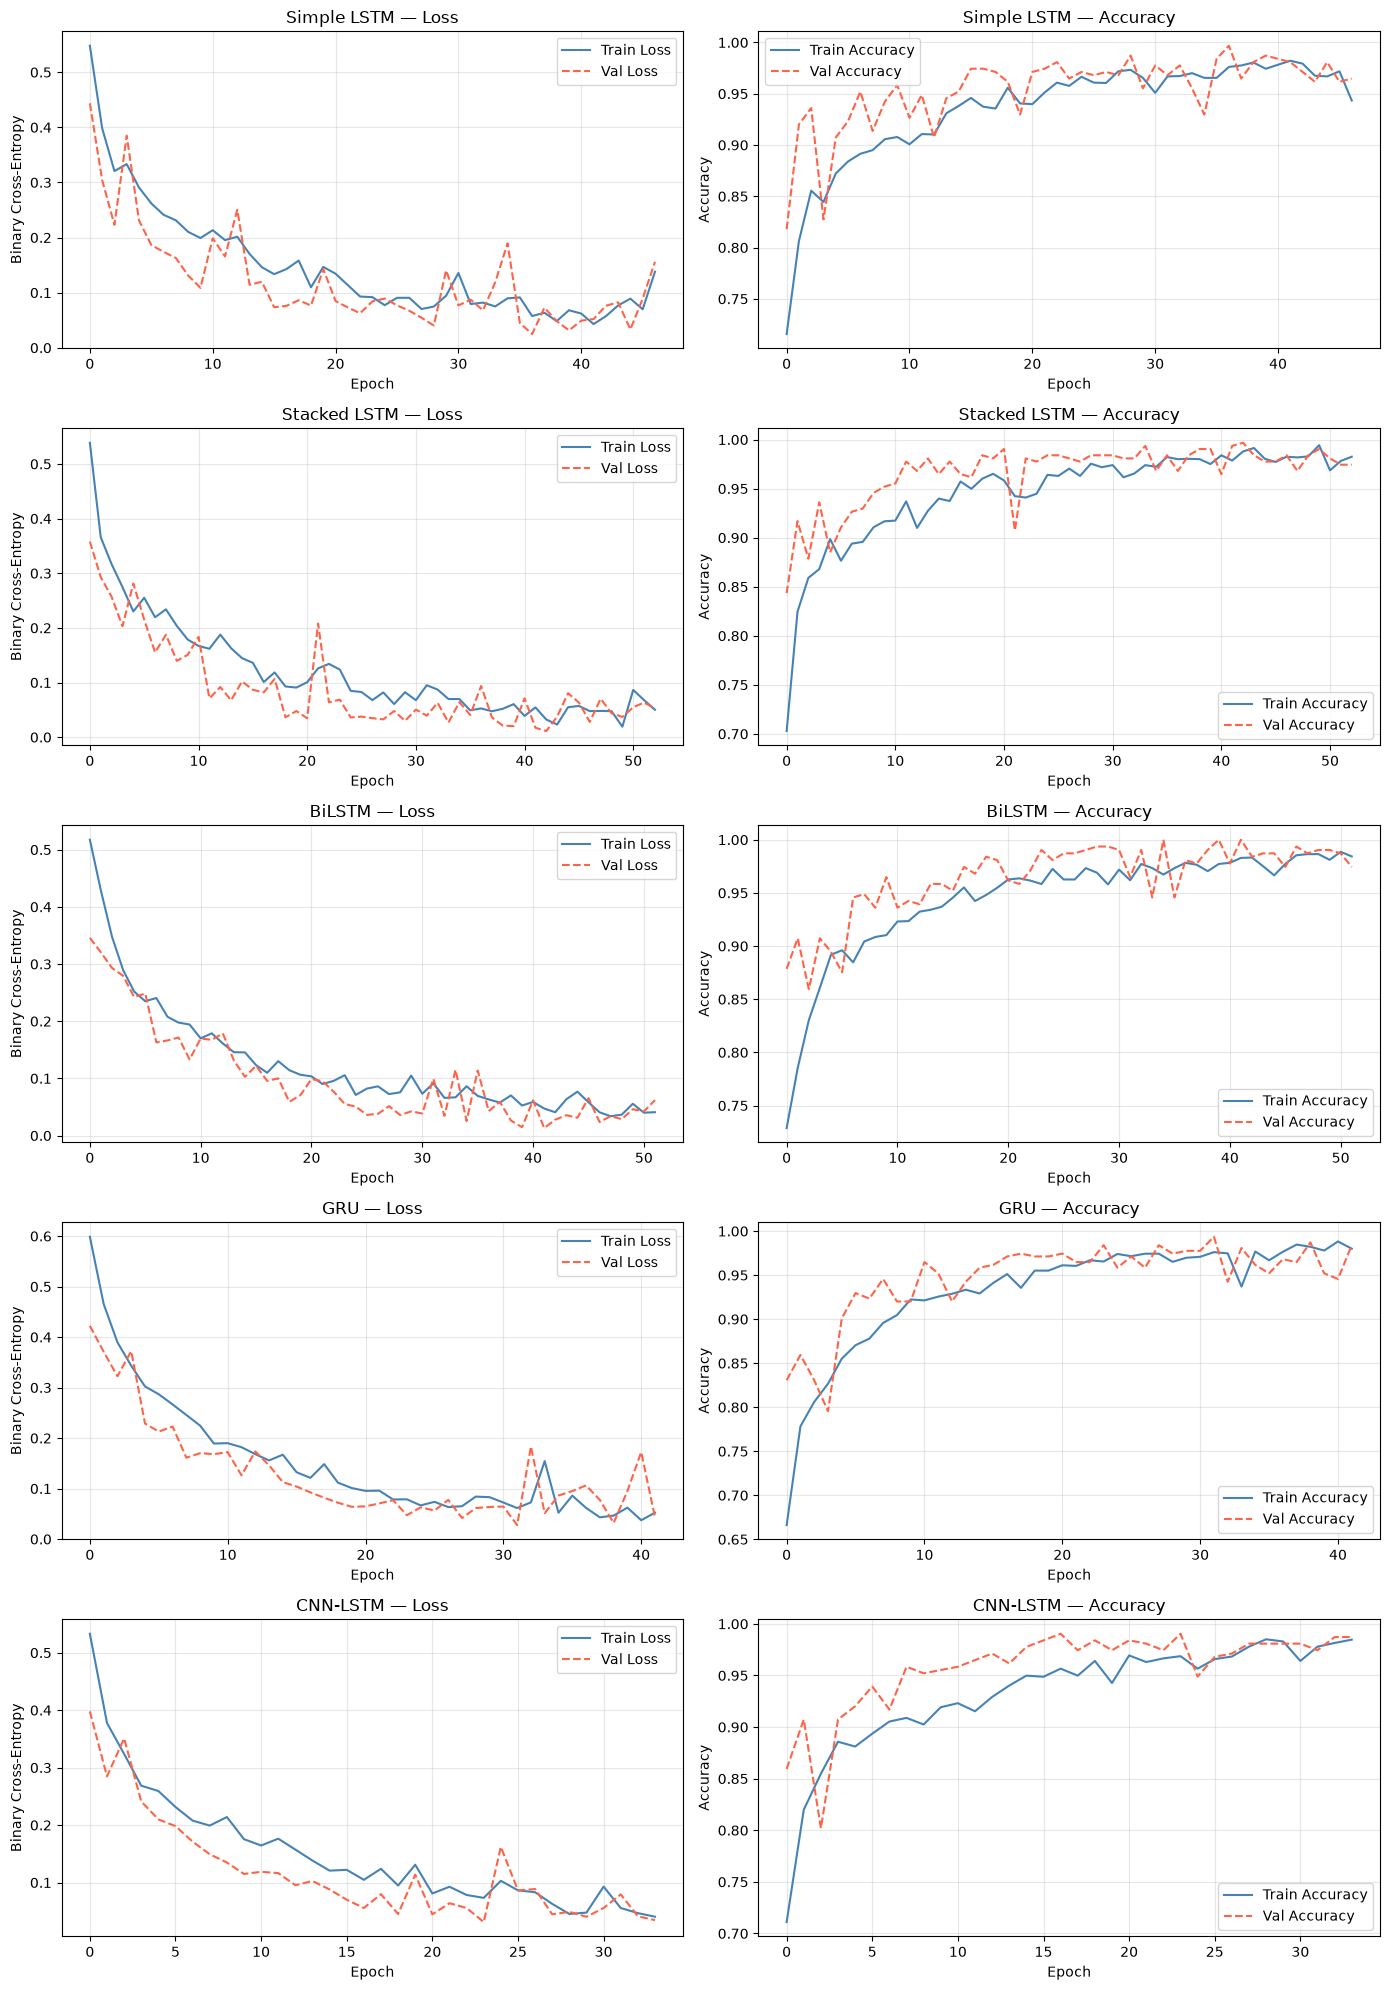

Learning curves saved.


In [15]:
#Plot learning curves

def plot_learning_curves(histories, names):
    """
    Plot training and validation loss + accuracy
    for all models side by side.
    """
    fig, axes = plt.subplots(len(names), 2, figsize=(14, 4 * len(names)))

    for i, (history, name) in enumerate(zip(histories, names)):
        # Loss
        axes[i, 0].plot(
            history.history['loss'],
            label='Train Loss',
            color='steelblue'
        )
        axes[i, 0].plot(
            history.history['val_loss'],
            label='Val Loss',
            color='tomato',
            linestyle='--'
        )
        axes[i, 0].set_title(f"{name} — Loss")
        axes[i, 0].set_xlabel("Epoch")
        axes[i, 0].set_ylabel("Binary Cross-Entropy")
        axes[i, 0].legend()
        axes[i, 0].grid(True, alpha=0.3)

        # Accuracy
        axes[i, 1].plot(
            history.history['accuracy'],
            label='Train Accuracy',
            color='steelblue'
        )
        axes[i, 1].plot(
            history.history['val_accuracy'],
            label='Val Accuracy',
            color='tomato',
            linestyle='--'
        )
        axes[i, 1].set_title(f"{name} — Accuracy")
        axes[i, 1].set_xlabel("Epoch")
        axes[i, 1].set_ylabel("Accuracy")
        axes[i, 1].legend()
        axes[i, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(
        os.path.join(LOGS_DIR, "learning_curves_all_models.png"),
        dpi=150
    )
    plt.show()
    print("Learning curves saved.")


all_histories = [
    history_simple_lstm,
    history_stacked_lstm,
    history_bilstm,
    history_gru,
    history_cnn_lstm
]
all_names = ["Simple LSTM", "Stacked LSTM", "BiLSTM", "GRU", "CNN-LSTM"]

plot_learning_curves(all_histories, all_names)

In [16]:
#Save model weights 

models_to_save = [
    (model_simple_lstm,  "simple_lstm"),
    (model_stacked_lstm, "stacked_lstm"),
    (model_bilstm,       "bilstm"),
    (model_gru,          "gru"),
    (model_cnn_lstm,     "cnn_lstm"),
]

for model, name in models_to_save:
    save_path = os.path.join(MODELS_DIR, f"{name}_final.keras")
    model.save(save_path)
    print(f"Saved: {save_path}")

# Save training histories for later use in evaluation notebook
histories_dict = {
    "simple_lstm"  : history_simple_lstm.history,
    "stacked_lstm" : history_stacked_lstm.history,
    "bilstm"       : history_bilstm.history,
    "gru"          : history_gru.history,
    "cnn_lstm"     : history_cnn_lstm.history,
}

with open(os.path.join(LOGS_DIR, "all_histories.pkl"), "wb") as f:
    pickle.dump(histories_dict, f)

print("\nAll models and histories saved.")
print(f"Models directory: {MODELS_DIR}")

Saved: /home/user/22059240/FYP/models/simple_lstm_final.keras
Saved: /home/user/22059240/FYP/models/stacked_lstm_final.keras
Saved: /home/user/22059240/FYP/models/bilstm_final.keras
Saved: /home/user/22059240/FYP/models/gru_final.keras
Saved: /home/user/22059240/FYP/models/cnn_lstm_final.keras

All models and histories saved.
Models directory: /home/user/22059240/FYP/models
